In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load all data (paths assume ../Data/ exists)
probes         = np.load('../Data/probes.npy')
subj           = np.load('../Data/subjs.npy')
subj_ses       = np.load('../Data/subjs_sep.npy', allow_pickle=True)
inout          = np.load('../Data/in.npy')
letters        = np.load('../Data/letters.npy')
letters_ses    = np.load('../Data/letters_sep.npy', allow_pickle=True)
probes_ses     = np.load('../Data/probes_sep.npy', allow_pickle=True)
units          = np.load('../Data/units.npy',allow_pickle=True)
completeBinned = np.load('../Data/binned.npy', allow_pickle=True)

# Subject/session metadata
sses          = [s[0] for s in subj_ses]
uniqueSub     = np.unique(sses)

# Letters (exclude rarely used or unwanted letters)
uniqueLetters = np.array([p for p in np.unique(letters) if p not in ['Q', 'W', 'X']])
n_labels      = len(uniqueLetters)

In [2]:
Y      = [np.array([[1 if u in letterString else 0 for u in uniqueLetters] for letterString in ls], dtype=int) for ls in letters_ses]
Yprobe = [np.array([[1 if u in letterString else 0 for u in uniqueLetters] for letterString in ls], dtype=int) for ls in probes_ses]

Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 1
Example (neuron, element, z, max_resp):


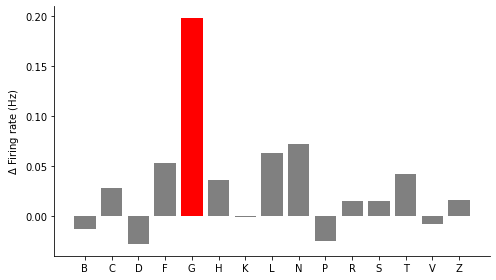

Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0
Example (neuron, element, z, max_resp):
Num selective neurons: 0


In [3]:
import matplotlib
font = {'weight' : 'normal',
        'size'   : 22}
matplotlib.rc('font', **font)

for sesID in range(len(Y)):
    yi = Y[sesID]
    xi = completeBinned[sesID]

    respALL = []
    for l in range(15):
        resp = np.mean(np.mean(xi[yi[:,l]==1,:,2:16],axis=-1),axis=0)-np.mean(np.mean(xi[yi[:,l]==0,:,2:16],axis=-1),axis=0)
        #print(resp.shape)
        respALL.append(resp/0.5)
        
    respALL = np.array(respALL)
    #respALL = np.array([r-np.min(r) for r in respALL.T])
    #respALL.shape

    import numpy as np

    # respALL: shape (15, n_neurons)
    E, N = respALL.shape

    max_idx = np.argmax(respALL, axis=0)          # (N,)
    max_val = respALL[max_idx, np.arange(N)]      # (N,)

    # mean/std across elements per neuron
    mu = respALL.mean(axis=0)                     # (N,)
    sd = respALL.std(axis=0, ddof=1) + 1e-12      # (N,)

    z = (max_val - mu) / sd                       # (N,)

    # choose a threshold (e.g., 3 = pretty strict, 4 = very strict)
    z_thresh = 3
    selective_neurons = np.where(z >= z_thresh)[0]

    # results
    winner_element  = max_idx[selective_neurons]
    winner_z        = z[selective_neurons]
    winner_response = max_val[selective_neurons]

    print("Num selective neurons:", len(selective_neurons))
    print("Example (neuron, element, z, max_resp):")
    #for i in range(min(10, len(selective_neurons))):
    #    n = selective_neurons[i]
    #    print(n, winner_element[i], winner_z[i], winner_response[i])
        
    n_elements = respALL.shape[0]
    for n in selective_neurons:
        vals = respALL[:, n]
        pref = np.argmax(vals)

        
        colors = ["gray"] * n_elements
        colors[pref] = "red"

        fig,ax = plt.subplots(figsize=(7, 4))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.bar(np.arange(n_elements), vals, color=colors)
        
        #plt.xlabel("Element")
        plt.ylabel("$\Delta$ Firing rate (Hz)")
        #plt.title(f"Neuron {n} (preferred element = {uniqueLetters[pref]})")

        plt.xticks(np.arange(n_elements),uniqueLetters)
        plt.tight_layout()
        plt.savefig('alignedNeuron.png',dpi=200)
        plt.show()      

Session 0 | Num selective neurons: 0
Session 1 | Num selective neurons: 0
Session 2 | Num selective neurons: 0
Session 3 | Num selective neurons: 0
Session 4 | Num selective neurons: 0
Session 5 | Num selective neurons: 0
Session 6 | Num selective neurons: 0
Session 7 | Num selective neurons: 0
Session 8 | Num selective neurons: 0
Session 9 | Num selective neurons: 1


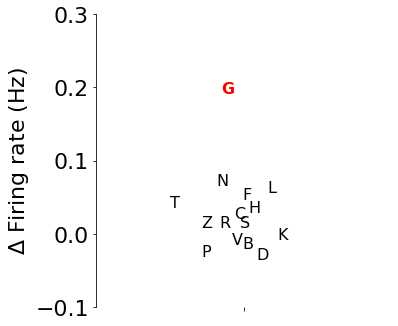

Session 10 | Num selective neurons: 0
Session 11 | Num selective neurons: 0
Session 12 | Num selective neurons: 0
Session 13 | Num selective neurons: 0
Session 14 | Num selective neurons: 0
Session 15 | Num selective neurons: 0
Session 16 | Num selective neurons: 0
Session 17 | Num selective neurons: 0
Session 18 | Num selective neurons: 0
Session 19 | Num selective neurons: 0
Session 20 | Num selective neurons: 0
Session 21 | Num selective neurons: 0
Session 22 | Num selective neurons: 0
Session 23 | Num selective neurons: 0
Session 24 | Num selective neurons: 0
Session 25 | Num selective neurons: 0
Session 26 | Num selective neurons: 0
Session 27 | Num selective neurons: 0
Session 28 | Num selective neurons: 0
Session 29 | Num selective neurons: 0
Session 30 | Num selective neurons: 0
Session 31 | Num selective neurons: 0
Session 32 | Num selective neurons: 0
Session 33 | Num selective neurons: 0
Session 34 | Num selective neurons: 0


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

font = {'weight': 'normal', 'size': 22}
matplotlib.rc('font', **font)

for sesID in range(len(Y)):
    yi = Y[sesID]
    xi = completeBinned[sesID]

    # --- compute respALL: (15, n_neurons)
    respALL = []
    for l in range(15):
        resp = (np.mean(np.mean(xi[yi[:, l] == 1, :, 2:16], axis=-1), axis=0)
              - np.mean(np.mean(xi[yi[:, l] == 0, :, 2:16], axis=-1), axis=0))
        respALL.append(resp / 0.5)
    respALL = np.asarray(respALL)  # (15, N)

    # --- selectivity logic (your original)
    E, N = respALL.shape
    max_idx = np.argmax(respALL, axis=0)               # (N,)
    max_val = respALL[max_idx, np.arange(N)]           # (N,)
    mu = respALL.mean(axis=0)                          # (N,)
    sd = respALL.std(axis=0, ddof=1) + 1e-12           # (N,)
    z = (max_val - mu) / sd                            # (N,)

    z_thresh = 3
    selective_neurons = np.where(z >= z_thresh)[0]

    print("Session", sesID, "| Num selective neurons:", len(selective_neurons))

    # --- ONE single boxplot per selective neuron:
    #     distribution = values across all letters (15 vals)
    for n in selective_neurons:

        vals = respALL[:, n]          # (15,)
        pref = int(np.argmax(vals))   # index of max letter

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.spines['top'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # --- Boxplot (no fill)
        """
        bp = ax.boxplot(
            [vals],
            positions=[1],
            widths=0.35,
            showfliers=True,
            patch_artist=False   # no colored box
        )
        """
        
        # --- Plot letters instead of dots
        rng = np.random.default_rng(0)
        x = 1 + rng.normal(0, 0.1, size=len(vals))  # small jitter

        for i, (xi, yi) in enumerate(zip(x, vals)):

            # max letter in red, others black
            if i == pref:
                color = "red"
                weight = "bold"
            else:
                color = "black"
                weight = "normal"

            ax.text(
                xi, yi,
                uniqueLetters[i],
                color=color,
                fontsize=16,
                fontweight=weight,
                ha="center",
                va="center",
                zorder=4
            )

        # --- Axis formatting
        ax.set_xticks([1])
        ax.set_xticklabels([f"Neuron {n}"], fontsize=18)
        ax.set_xticklabels([])

        ax.set_ylabel(r"$\Delta$ Firing rate (Hz)")
        ax.set_ylim(-0.1,+0.3)
        ax.set_xlim(0.5,1.5)
        '''
        # annotate preferred letter
        ax.text(
            0.02, 0.98,
            f"Max letter: {uniqueLetters[pref]} ({vals[pref]:.2f})",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=15
        )
        '''
        
        plt.tight_layout()
        plt.savefig(f"selectiveNeuron_{n}_ses{sesID}.svg", dpi=200)
        plt.show()

In [27]:
import numpy as np


# -----------------------
# Core computations
# -----------------------

def compute_respALL(xdat, yi, t0=2, t1=16, bin_width_s=0.5):
    """
    Compute Δ firing rate (Hz) for each letter.

    xdat: (n_trials, n_neurons, n_timebins)
    yi:   (n_trials, 15)
    returns: (15, N)
    """

    n_trials, n_neurons, _ = xdat.shape
    n_letters = yi.shape[1]

    respALL = np.full((n_letters, n_neurons), np.nan)

    # average over time window
    xw = np.mean(xdat[:, :, t0:t1], axis=-1)  # (trials, neurons)

    for l in range(n_letters):

        m1 = yi[:, l] == 1
        m0 = yi[:, l] == 0

        # protect against empty splits
        if np.any(m1) and np.any(m0):
            diff = np.abs(np.mean(xw[m1, :], axis=0) - np.mean(xw[m0, :], axis=0))
            respALL[l, :] = diff / bin_width_s

    return respALL


def compute_z(respALL):
    """
    Compute z-score per neuron:
      (max - mean) / std  across letters

    respALL: (15, N)
    returns: (N,)
    """

    max_val = np.nanmax(respALL, axis=0)
    mu = np.nanmean(respALL, axis=0)
    sd = np.nanstd(respALL, axis=0, ddof=1) + 1e-12

    z = (max_val - mu) / sd

    return z


def permutation_test_z(xdat, yi, n_perm=2000, seed=0,
                       t0=2, t1=16, bin_width_s=0.5):
    """
    Run permutation test on z-score.

    Returns:
      z_obs   (N,)
      z_perm  (n_perm, N)
      pvals   (N,)
    """

    rng = np.random.default_rng(seed)

    # ----- observed
    respALL_obs = compute_respALL(
        xdat, yi, t0=t0, t1=t1, bin_width_s=bin_width_s
    )

    z_obs = compute_z(respALL_obs)

    n_letters, N = respALL_obs.shape

    # ----- permutations
    z_perm = np.full((n_perm, N), np.nan)

    for p in range(n_perm):

        yi_perm = yi.copy()

        # permute trials within each letter
        for l in range(n_letters):
            perm_idx = rng.permutation(yi_perm.shape[0])
            yi_perm[:, l] = yi_perm[perm_idx, l]

        respALL_p = compute_respALL(
            xdat, yi_perm, t0=t0, t1=t1, bin_width_s=bin_width_s
        )

        z_perm[p, :] = compute_z(respALL_p)

    # ----- p-values (one-sided: high z)
    pvals = np.full(N, np.nan)

    valid = np.isfinite(z_obs)

    if np.any(valid):
        pvals[valid] = (
            1.0
            + np.sum(z_perm[:, valid] >= z_obs[None, valid], axis=0)
        ) / (n_perm + 1.0)

    return z_obs, z_perm, pvals


# -----------------------
# Run across sessions
# -----------------------

# Settings
n_perm = 2000
alpha = 0.05
seed = 0

summary = []

print("\n===== Permutation z-test summary =====\n")

for sesID in range(len(Y)):

    yi = Y[sesID]
    xdat = completeBinned[sesID]

    z_obs, z_perm, pvals = permutation_test_z(
        xdat, yi,
        n_perm=n_perm,
        seed=seed,
        t0=2, t1=16,
        bin_width_s=0.5
    )

    # significant neurons
    sig_idx = np.where(pvals < alpha)[0]

    n_total = len(z_obs)
    n_sig = len(sig_idx)
    frac = n_sig / n_total

    summary.append((sesID, n_total, n_sig, frac))

    print(
        f"Session {sesID:2d} | "
        f"Total neurons: {n_total:4d} | "
        f"Significant: {n_sig:4d} | "
        f"Fraction: {frac:.3f}"
    )


# -----------------------
# Optional: grand summary
# -----------------------

tot_neurons = np.sum([s[1] for s in summary])
tot_sig = np.sum([s[2] for s in summary])

print("\n===== Overall =====")
print(f"Total neurons:     {tot_neurons}")
print(f"Total significant: {tot_sig}")
print(f"Overall fraction:  {tot_sig / tot_neurons:.3f}")


===== Permutation z-test summary =====

Session  0 | Total neurons:   14 | Significant:    2 | Fraction: 0.143
Session  1 | Total neurons:   16 | Significant:    0 | Fraction: 0.000
Session  2 | Total neurons:   15 | Significant:    0 | Fraction: 0.000
Session  3 | Total neurons:   31 | Significant:    3 | Fraction: 0.097
Session  4 | Total neurons:   29 | Significant:    4 | Fraction: 0.138
Session  5 | Total neurons:   33 | Significant:    2 | Fraction: 0.061
Session  6 | Total neurons:   27 | Significant:    1 | Fraction: 0.037
Session  7 | Total neurons:   19 | Significant:    1 | Fraction: 0.053
Session  8 | Total neurons:   52 | Significant:    3 | Fraction: 0.058
Session  9 | Total neurons:   70 | Significant:    7 | Fraction: 0.100
Session 10 | Total neurons:   28 | Significant:    1 | Fraction: 0.036
Session 11 | Total neurons:   25 | Significant:    0 | Fraction: 0.000
Session 12 | Total neurons:   20 | Significant:    1 | Fraction: 0.050
Session 13 | Total neurons:   15 | S

In [30]:
from scipy.stats import binomtest

res = binomtest(64, 996, alpha, alternative="greater")

print(res.pvalue)

0.026503003320196505


Session 0 | Num selective neurons: 1


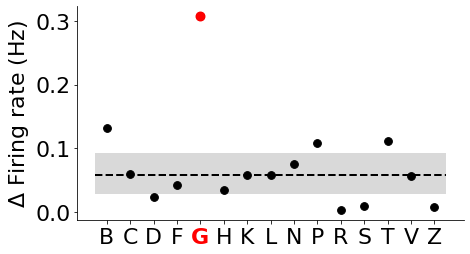

Session 1 | Num selective neurons: 0
Session 2 | Num selective neurons: 0
Session 3 | Num selective neurons: 1


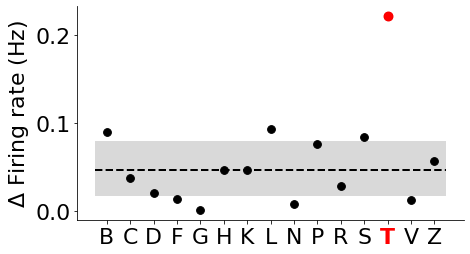

Session 4 | Num selective neurons: 1


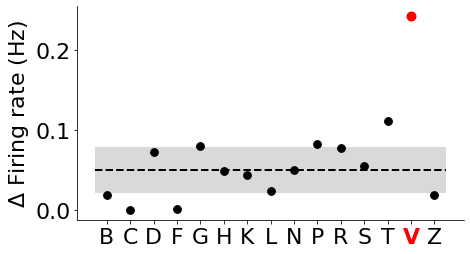

Session 5 | Num selective neurons: 1


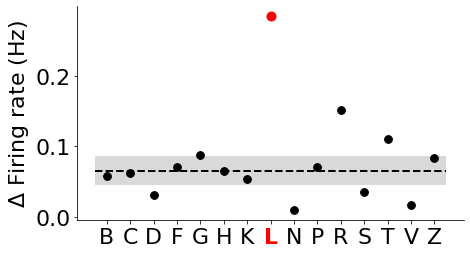

Session 6 | Num selective neurons: 1


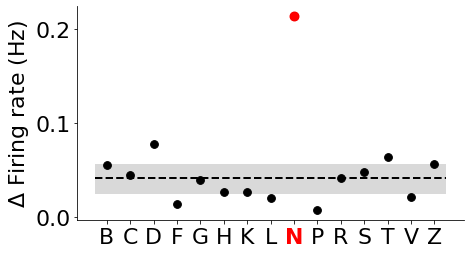

Session 7 | Num selective neurons: 0
Session 8 | Num selective neurons: 0
Session 9 | Num selective neurons: 4


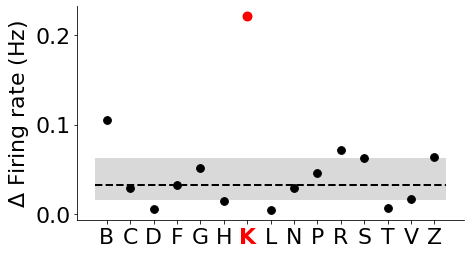

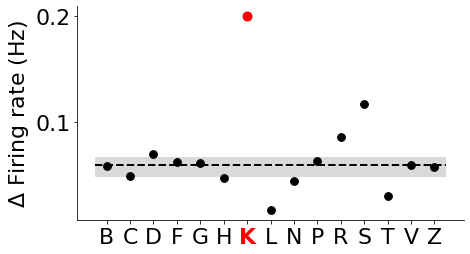

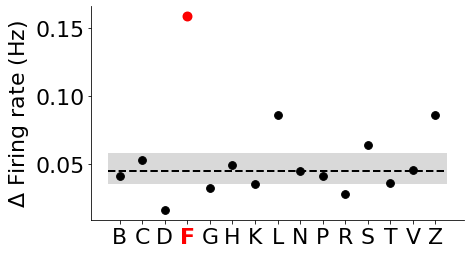

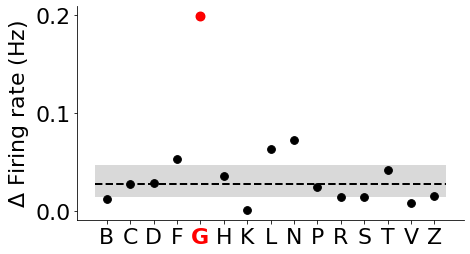

Session 10 | Num selective neurons: 0
Session 11 | Num selective neurons: 0
Session 12 | Num selective neurons: 1


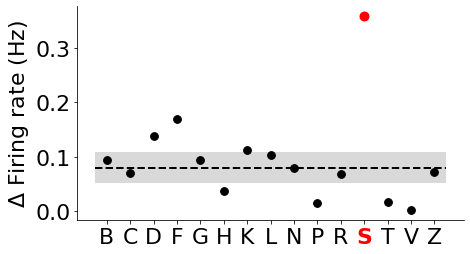

Session 13 | Num selective neurons: 0
Session 14 | Num selective neurons: 0
Session 15 | Num selective neurons: 1


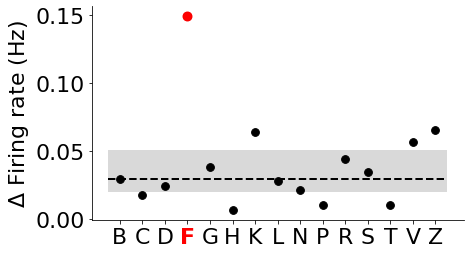

Session 16 | Num selective neurons: 0
Session 17 | Num selective neurons: 0
Session 18 | Num selective neurons: 1


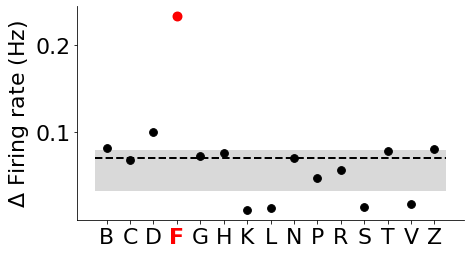

Session 19 | Num selective neurons: 0
Session 20 | Num selective neurons: 2


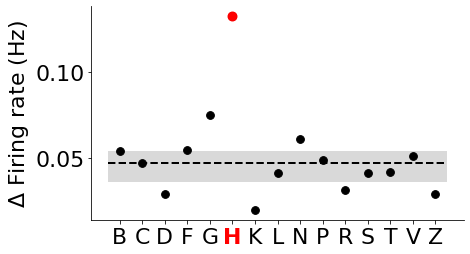

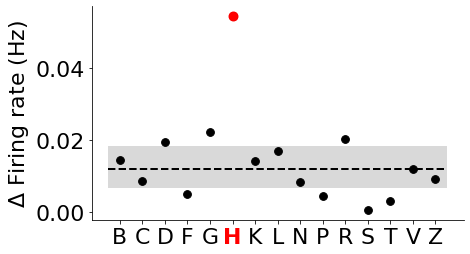

Session 21 | Num selective neurons: 0
Session 22 | Num selective neurons: 0
Session 23 | Num selective neurons: 2


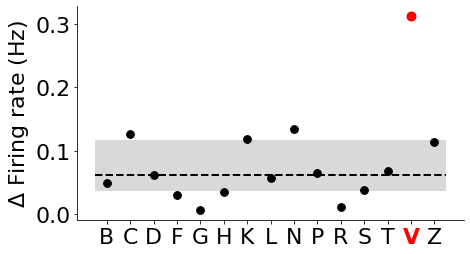

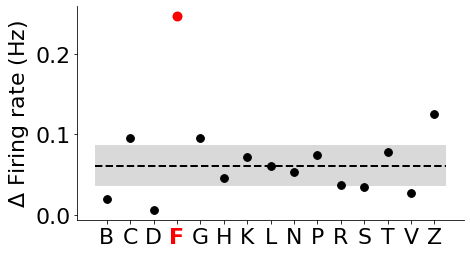

Session 24 | Num selective neurons: 3


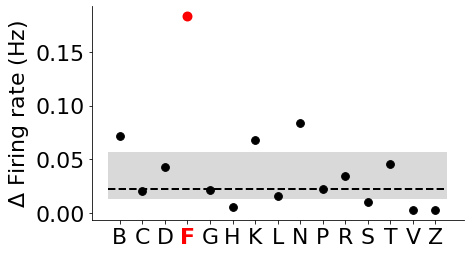

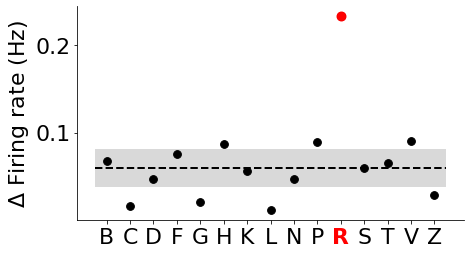

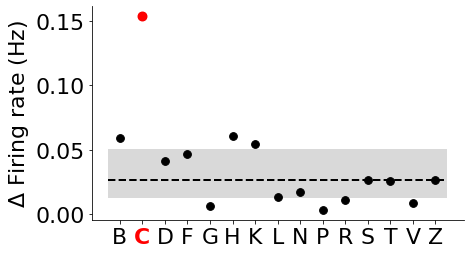

Session 25 | Num selective neurons: 1


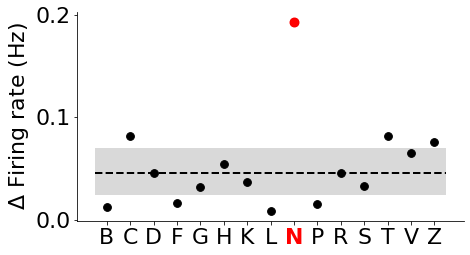

Session 26 | Num selective neurons: 4


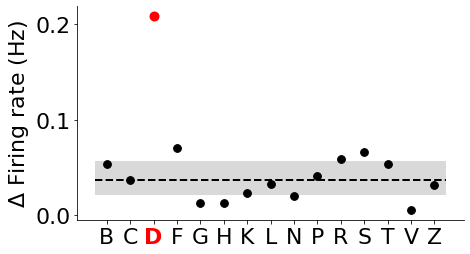

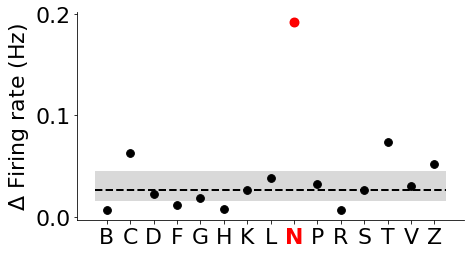

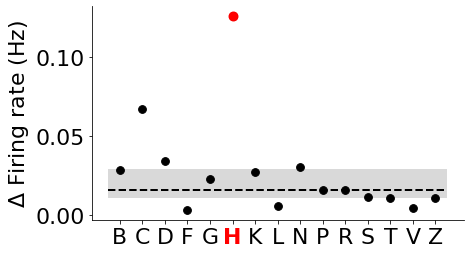

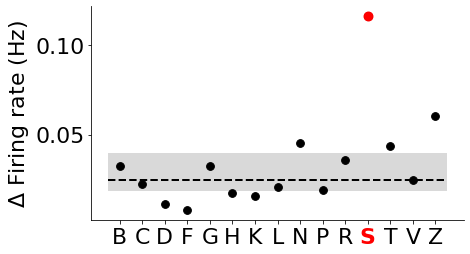

Session 27 | Num selective neurons: 0
Session 28 | Num selective neurons: 0
Session 29 | Num selective neurons: 0
Session 30 | Num selective neurons: 0
Session 31 | Num selective neurons: 0
Session 32 | Num selective neurons: 0
Session 33 | Num selective neurons: 0
Session 34 | Num selective neurons: 0


In [70]:
from scipy.stats import iqr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

font = {'weight': 'normal', 'size': 22}
matplotlib.rc('font', **font)

for sesID in range(len(Y)):
    yi = Y[sesID]
    xdat = completeBinned[sesID]

    # --- compute respALL: (15, n_neurons)
    respALL = []
    for l in range(15):
        resp = (np.mean(np.mean(xdat[yi[:, l] == 1, :, 2:16], axis=-1), axis=0)
              - np.mean(np.mean(xdat[yi[:, l] == 0, :, 2:16], axis=-1), axis=0))
        respALL.append(np.abs(resp) / 0.5)
    respALL = np.asarray(respALL)  # (15, N)

    # --- selectivity logic (your original)
    E, N = respALL.shape
    max_idx = np.argmax(respALL, axis=0)               # (N,)
    max_val = respALL[max_idx, np.arange(N)]           # (N,)
    mu = respALL.mean(axis=0)                          # (N,)
    sd = respALL.std(axis=0, ddof=1) + 1e-12           # (N,)
    z = (max_val - mu) / sd                            # (N,)

    z_thresh = 3
    selective_neurons = np.where(z >= z_thresh)[0]
    print("Session", sesID, "| Num selective neurons:", len(selective_neurons))

    n_elements = respALL.shape[0]

    
    for n in selective_neurons:
        vals = respALL[:, n]
        pref = np.argmax(vals)

        x = np.arange(n_elements)

        # Median and IQR
        med = np.median(vals)
        q1 = np.percentile(vals, 25)
        q3 = np.percentile(vals, 75)

        fig, ax = plt.subplots(figsize=(7, 4))

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Plot dots
        ax.scatter(x, vals, color="k", s=60, zorder=3)

        # Highlight preferred element dot
        ax.scatter(pref, vals[pref], color="red", s=80, zorder=4)

        # Median line
        ax.hlines(
            med,
            xmin=-0.5,
            xmax=n_elements - 0.5,
            colors="black",
            linestyles="--",
            linewidth=2
        )

        # IQR band
        ax.fill_between(
            [-0.5, n_elements - 0.5],
            q1,
            q3,
            color="black",
            alpha=0.15,
            linewidth=0
        )

        ax.set_ylabel(r"$\Delta$ Firing rate (Hz)")

        # X ticks
        ax.set_xticks(x)
        ax.set_xticklabels(uniqueLetters)

        # Make highest-response letter red
        for i, label in enumerate(ax.get_xticklabels()):
            if i == pref:
                label.set_color("red")
                label.set_fontweight("bold")

        plt.tight_layout()
        if(sesID==0):
            plt.savefig("alignedNeuron.png", dpi=200)
        plt.show()